<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Epoch 1/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0014 - mae: 0.0145 - val_loss: 0.0010 - val_mae: 0.0207
Epoch 2/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 6.8840e-04 - mae: 0.0107 - val_loss: 4.5600e-04 - val_mae: 0.0021
Epoch 3/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.8980e-04 - mae: 0.0077 - val_loss: 4.6242e-04 - val_mae: 0.0026
Epoch 4/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5.6729e-04 - mae: 0.0081 - val_loss: 4.5343e-04 - val_mae: 0.0021
Epoch 5/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 4.1268e-04 - mae: 0.0063 - val_loss: 4.6027e-04 - val_mae: 0.0047
Epoch 6/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3.6019e-04 - mae: 0.0061 - val_loss: 6.1922e-04 - val_mae: 0.0103
Epoch 7/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 6.1073e-04 - mae: 0.0086 - val_loss: 4.9133e-04 - val_mae: 0.0065
Epoch 8/100
1280/1280 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.2277e-04 - mae: 0.0073 - val_loss: 5.588

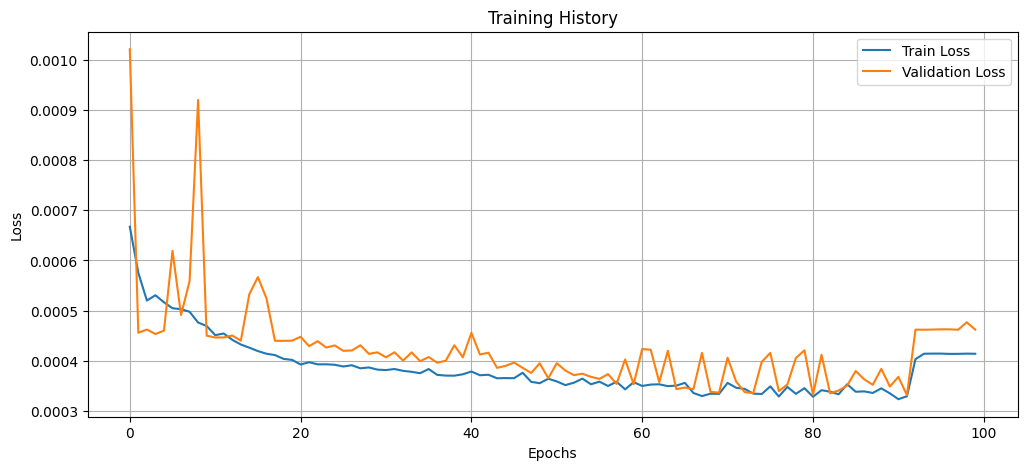

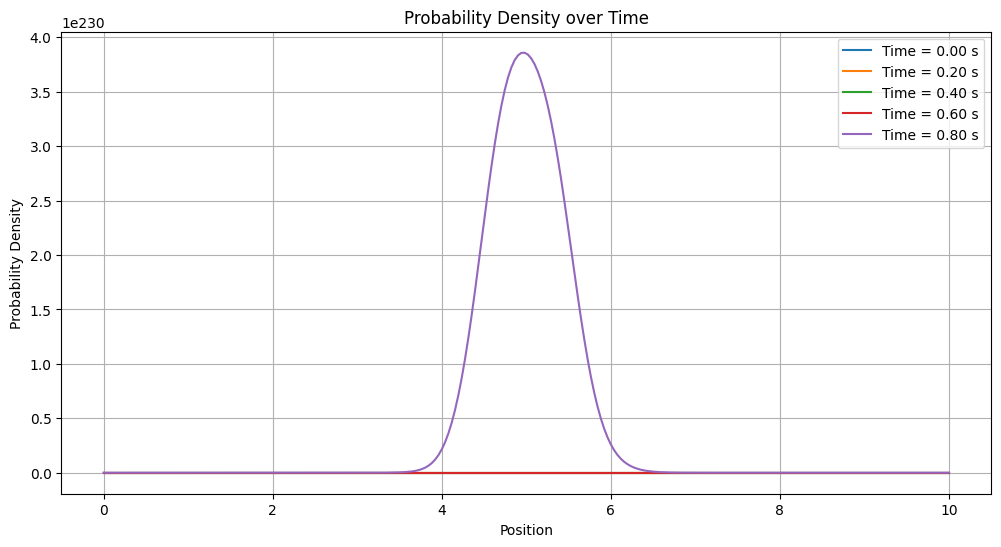

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from google.colab import files

# Parameters for the Schrödinger Equation
L = 10.0
T = 1.0
nx = 256
nt = 200
hbar = 1.0
m = 1.0
dx = L / (nx - 1)
dt = T / nt

# Initial condition: Gaussian wave packet
x = np.linspace(0, L, nx)
x0 = 5.0
sigma = 0.5
k0 = 5.0
A = 1.0

# Initialize wave function
psi = A * np.exp(-(x - x0)**2 / (2 * sigma**2)) * np.exp(1j * k0 * x)
Psi = np.zeros((nt, nx), dtype=complex)
Psi[0, :] = psi

# Time-stepping loop (finite difference method)
for n in range(0, nt - 1):
    for i in range(1, nx - 1):
        Psi[n + 1, i] = Psi[n, i] - (1j * hbar * dt / (2 * m * dx**2)) * (Psi[n, i + 1] - 2 * Psi[n, i] + Psi[n, i - 1])

# Prepare the dataset for training
X = np.zeros((nt * nx, 2))
Y = np.zeros((nt * nx, 1))

for n in range(nt):
    for i in range(nx):
        X[n * nx + i, 0] = x[i]          # Position
        X[n * nx + i, 1] = n * dt         # Time
        Y[n * nx + i, 0] = np.abs(Psi[n, i])**2  # Probability density

# Normalize features and labels
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_normalized = (X - X_min) / (X_max - X_min)

Y_min = Y.min()
Y_max = Y.max()
Y_normalized = (Y - Y_min) / (Y_max - Y.min())

# Split the dataset
X_train, X_val, Y_train, Y_val = train_test_split(X_normalized, Y_normalized, test_size=0.2, random_state=42)

# Save the dataset
np.savez('schrodinger_dataset.npz', X=X, Y=Y)

# Download the dataset
files.download('schrodinger_dataset.npz')

# Define the neural network model
model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    layers.Dense(1)
])

# Compile the model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])

# Train the model
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=100, batch_size=32)

# Plot training history
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Plotting probability density at different time steps
plt.figure(figsize=(12, 6))
for n in range(0, nt, nt // 5):
    plt.plot(x, np.abs(Psi[n, :])**2, label=f'Time = {n * dt:.2f} s')

plt.title('Probability Density over Time')
plt.xlabel('Position')
plt.ylabel('Probability Density')
plt.legend()
plt.grid()
plt.show()
